# Applied Machine Learning - Homework 4
## TinyML: Network Compression & Model Optimization

### Learning Objectives
By completing this homework, you will:
1. Understand the need for model compression in resource-constrained environments
2. Implement network pruning to remove redundant parameters
3. Explore parameter quantization to reduce model size and inference time
4. Understand knowledge distillation for training smaller models
5. Analyze trade-offs between model size, accuracy, and efficiency
6. Compare different compression techniques for TinyML deployment

### Instructions
- Complete all TODO sections marked with `# TODO: [Task Description]`
- Run all cells to ensure your implementation works
- Answer the reflection questions in markdown cells
- **Do not modify the provided test functions or baseline code structure**

---

## Setup and Imports

In [4]:
# Essential imports for the homework
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('default')
sns.set_palette("husl")

print("✅ All imports successful!")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

✅ All imports successful!
NumPy version: 2.4.2
Matplotlib version: 3.10.8


---
# Part 1: Network Pruning

Network pruning removes redundant or less important connections (weights) from a trained neural network to reduce model size and computation.

### Task 1.1: Build a Simple Neural Network

In [5]:
class SimpleNN:
    """
    A simple 2-layer neural network for classification.
    """
    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights with small random values
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))
        
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)
    
    def forward(self, X):
        # TODO: Implement forward pass
        # Layer 1: z1 = X @ W1 + b1
        # Layer 1 activation: a1 = sigmoid(z1)
        # Layer 2: z2 = a1 @ W2 + b2
        # Output: y = softmax(z2)
        
        self.z1 = X @ self.W1 + self.b1  # Already implemented
        self.a1 = self.sigmoid(self.z1)  # Replace with sigmoid activation
        self.z2 = self.a1 @ self.W2 + self.b2  # Replace with layer 2 computation
        output = self.softmax(self.z2)   # Replace with softmax output
        
        return output
    
    def predict(self, X):
        output = self.forward(X)
        return np.argmax(output, axis=1)
    
    def count_parameters(self):
        # TODO: Calculate total number of parameters
        # Total = W1 + b1 + W2 + b2
        total = self.W1.size + self.b1.size + self.W2.size + self.b2.size  # Replace with calculation
        return total
    
    def count_nonzero_parameters(self):
        # TODO: Count non-zero parameters (for pruned networks)
        # Use np.count_nonzero() for each weight matrix
        nonzero = (
            np.count_nonzero(self.W1) +
            np.count_nonzero(self.b1) +
            np.count_nonzero(self.W2) +
            np.count_nonzero(self.b2)
        )  # Replace with calculation
        return nonzero

# Load a simple dataset for testing
digits = load_digits()
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42
)

# Normalize data
X_train = X_train / 16.0
X_test = X_test / 16.0

# Create and initialize network
input_size = X_train.shape[1]  # 64 features (8x8 images)
hidden_size = 128
output_size = 10  # 10 digit classes

model = SimpleNN(input_size, hidden_size, output_size)

print(f"Network Architecture:")
print(f"  Input layer: {input_size} neurons")
print(f"  Hidden layer: {hidden_size} neurons")
print(f"  Output layer: {output_size} neurons")
print(f"\nDataset: {X_train.shape[0]} training samples, {X_test.shape[0]} test samples")
if model.count_parameters():
    print(f"Total parameters: {model.count_parameters():,}")

Network Architecture:
  Input layer: 64 neurons
  Hidden layer: 128 neurons
  Output layer: 10 neurons

Dataset: 1437 training samples, 360 test samples
Total parameters: 9,610


### Task 1.2: Implement Magnitude-Based Pruning

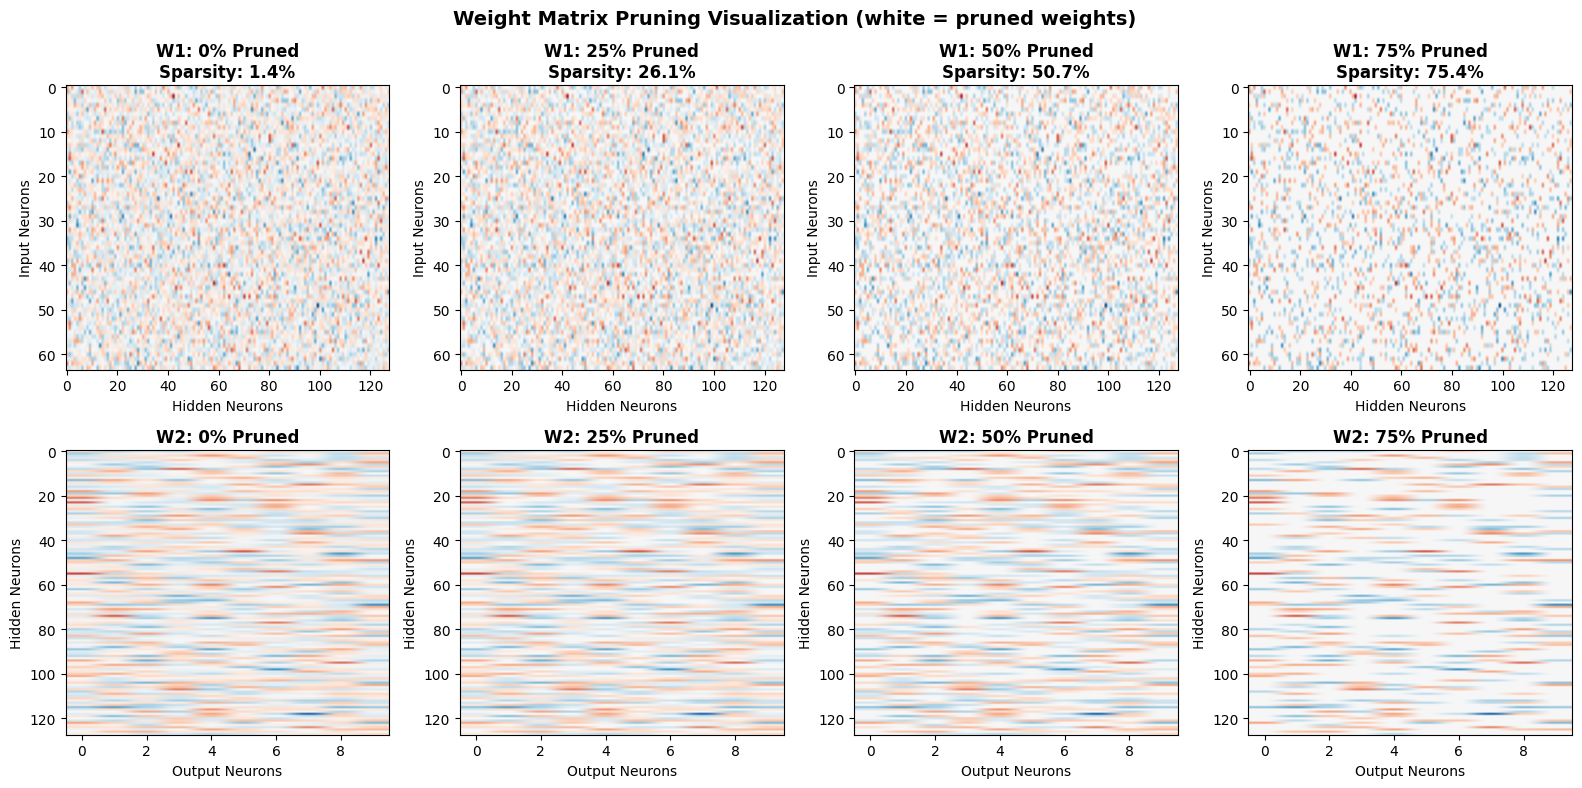

In [6]:
def prune_weights_magnitude(model, pruning_percentage):
    """
    Prune weights based on magnitude (set smallest weights to zero).
    
    Args:
        model: SimpleNN instance
        pruning_percentage: Percentage of weights to remove (0-100)
        
    Returns:
        Pruned model
    """
    # TODO: Implement magnitude-based pruning
    # Steps:
    # 1. Concatenate all weights into a single array
    # 2. Calculate threshold using np.percentile()
    # 3. Set weights below threshold to zero
    
    # Collect all weights
    all_weights = np.concatenate([
        np.abs(model.W1.flatten()),
        np.abs(model.W2.flatten())
    ])
    
    # TODO: Calculate threshold (weights below this will be pruned)
    # Hint: Use np.percentile(all_weights, pruning_percentage)
    threshold = np.percentile(all_weights, pruning_percentage)  # Replace with calculation
    
    # TODO: Apply pruning mask to W1
    # Create mask: model.W1 = np.where(np.abs(model.W1) < threshold, 0, model.W1)
    # (This sets values below threshold to 0, keeps others)
    model.W1 = np.where(np.abs(model.W1) < threshold, 0, model.W1)
    
    # TODO: Apply pruning mask to W2
    model.W2 = np.where(np.abs(model.W2) < threshold, 0, model.W2)
    
    return model

def visualize_pruning_effect():
    """
    Visualize the effect of pruning on weight matrices.
    """
    # Create a test model
    test_model = SimpleNN(64, 128, 10)
    
    # Store original weights
    W1_original = test_model.W1.copy()
    W2_original = test_model.W2.copy()
    
    # Apply different pruning percentages
    pruning_levels = [0, 25, 50, 75]
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    for idx, prune_pct in enumerate(pruning_levels):
        # Reset model
        test_model.W1 = W1_original.copy()
        test_model.W2 = W2_original.copy()
        
        # Apply pruning
        prune_weights_magnitude(test_model, prune_pct)
        
        # Count remaining weights
        total_params = test_model.count_parameters()
        nonzero_params = test_model.count_nonzero_parameters()
        
        if nonzero_params and total_params:
            sparsity = (1 - nonzero_params / total_params) * 100
        else:
            sparsity = 0
        
        # Visualize W1
        axes[0, idx].imshow(test_model.W1, cmap='RdBu', aspect='auto', vmin=-0.05, vmax=0.05)
        axes[0, idx].set_title(f'W1: {prune_pct}% Pruned\nSparsity: {sparsity:.1f}%', fontweight='bold')
        axes[0, idx].set_ylabel('Input Neurons')
        axes[0, idx].set_xlabel('Hidden Neurons')
        
        # Visualize W2
        axes[1, idx].imshow(test_model.W2, cmap='RdBu', aspect='auto', vmin=-0.05, vmax=0.05)
        axes[1, idx].set_title(f'W2: {prune_pct}% Pruned', fontweight='bold')
        axes[1, idx].set_ylabel('Hidden Neurons')
        axes[1, idx].set_xlabel('Output Neurons')
    
    plt.suptitle('Weight Matrix Pruning Visualization (white = pruned weights)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run visualization
visualize_pruning_effect()

### Reflection Question 1.1
**Answer the following questions:**

1. What is the principle behind magnitude-based pruning? Why do we remove small weights?
2. Looking at the visualizations, what happens to the weight matrices as pruning percentage increases?
3. What is "sparsity" in the context of neural networks?
4. What are potential downsides of aggressive pruning (e.g., 75% or more)?

**Your Answer:**
<!-- TODO: Replace this comment with your detailed answers -->
1. Magnitude-based pruning removes weights with the smallest absolute values because these weights contribute the least to the network’s output. By eliminating them, we can simplify the model and reduce its size with minimal impact on performance.

2. As the pruning percentage increases, more weights in the matrices are set to zero. The visualizations show that the matrices become increasingly sparse, with more white (zero) regions, indicating that many connections have been removed.

3. "Sparsity" in neural networks refers to the proportion of weights that are zero. Higher sparsity means more weights are zero, resulting in a network with fewer active connections.

4. Aggressive pruning (e.g., 75% or more) can remove too many important weights, which may significantly reduce the model’s accuracy and its ability to generalize. It can also lead to disconnected neurons or layers, making the network less expressive and harder to train or fine-tune.

---
## ✅ Part 1 Checklist: Network Pruning

**Before proceeding to Part 2, make sure you have completed all the following tasks:**

### Neural Network Implementation:
- [ ] **TODO 1.1**: Implemented `a1 = self.sigmoid(self.z1)`
- [ ] **TODO 1.2**: Implemented `z2 = a1 @ self.W2 + self.b2`
- [ ] **TODO 1.3**: Implemented `output = self.softmax(z2)`
- [ ] **TODO 1.4**: Calculated total parameters (W1.size + b1.size + W2.size + b2.size)
- [ ] **TODO 1.5**: Counted non-zero parameters using np.count_nonzero()
- [ ] **Verification**: Network displays total parameter count

### Pruning Implementation:
- [ ] **TODO 1.6**: Calculated threshold using `np.percentile(all_weights, pruning_percentage)`
- [ ] **TODO 1.7**: Applied pruning mask to W1
- [ ] **TODO 1.8**: Applied pruning mask to W2
- [ ] **Verification**: Pruning visualization shows increasing sparsity
- [ ] **Verification**: Weight matrices show white (zero) regions after pruning

### Understanding Tasks:
- [ ] **Reflection 1.1**: Answered all four questions about pruning principles and effects
- [ ] **Concept Check**: Understand magnitude-based pruning removes smallest weights
- [ ] **Concept Check**: Understand sparsity = percentage of zero weights

**🎯 Goal**: Successfully implement network pruning and understand its effects on model structure.

---

---
# Part 2: Parameter Quantization

Quantization reduces the precision of weights and activations from 32-bit floating point to lower bit representations (e.g., 8-bit integers).

### Task 2.1: Implement Weight Quantization

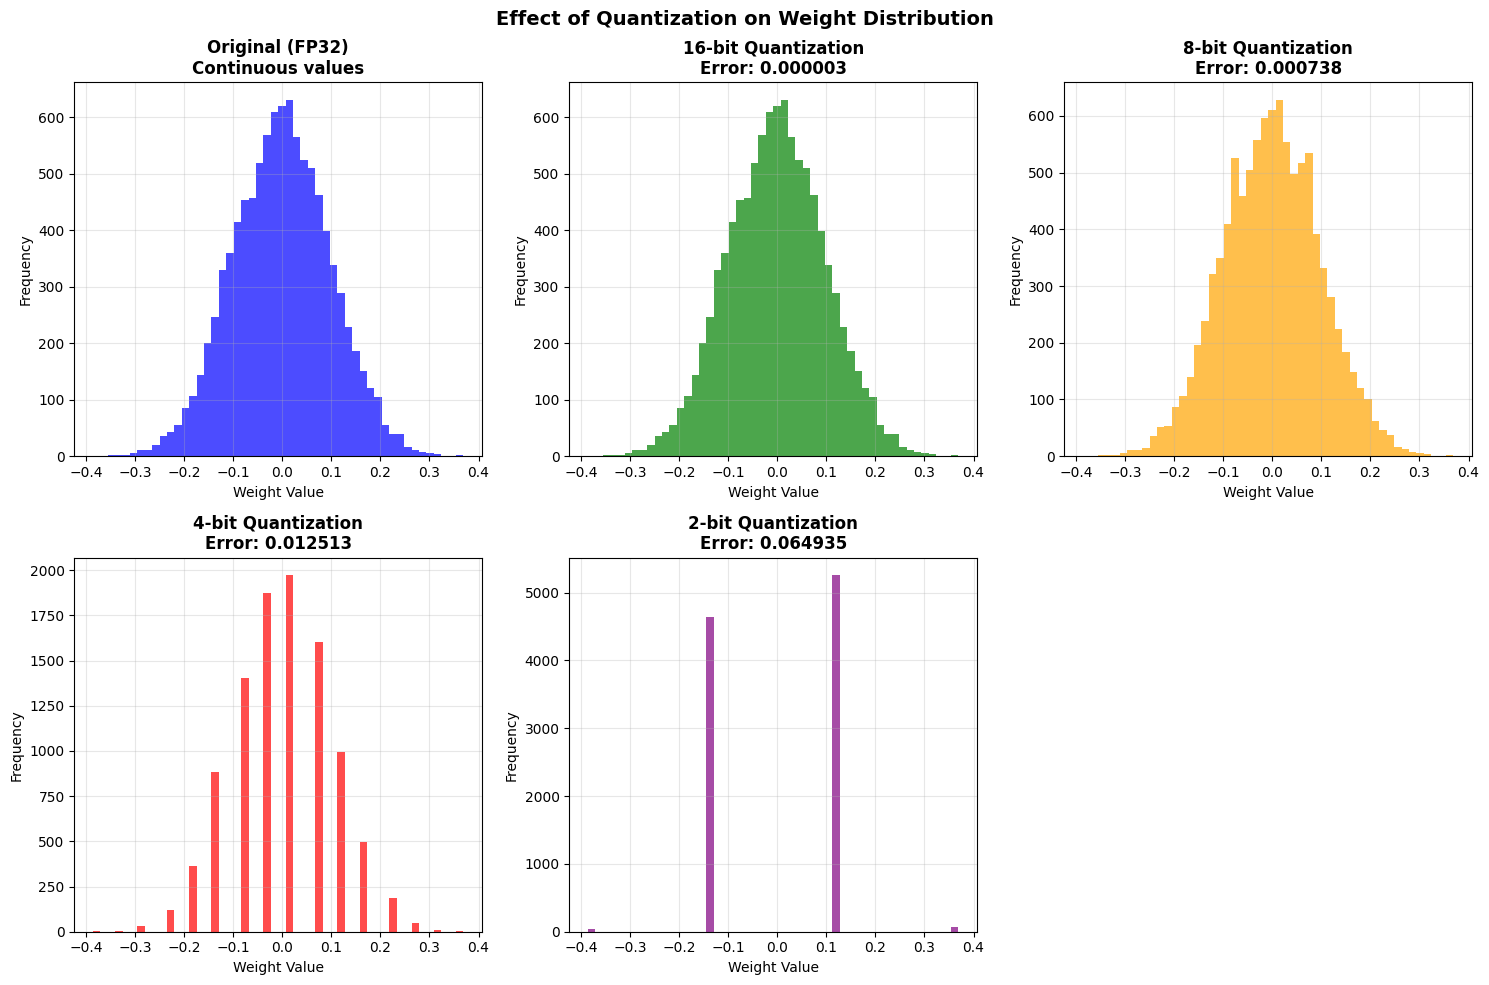


📊 Memory Size Comparison:
32-bit: 40,000 bytes (Reduction: 50.0%)
16-bit: 20,000 bytes (Reduction: 75.0%)
8-bit: 10,000 bytes (Reduction: 87.5%)
4-bit: 5,000 bytes (Reduction: 93.8%)
2-bit: 2,500 bytes (Reduction: 96.9%)


In [7]:
def quantize_weights(weights, num_bits=8):
    """
    Quantize weights to lower bit precision.
    
    Args:
        weights: Float32 weight matrix
        num_bits: Target bit precision (e.g., 8 for int8)
        
    Returns:
        Quantized weights, scale, zero_point
    """
    # TODO: Implement symmetric quantization
    # Steps:
    # 1. Find min and max of weights
    # 2. Calculate scale factor
    # 3. Quantize to integer range
    # 4. Dequantize back to float (for comparison)
    
    # Find range
    w_min = np.min(weights)
    w_max = np.max(weights)
    
    # TODO: Calculate number of quantization levels
    # levels = 2^num_bits
    num_levels = 2 ** num_bits  # Replace with 2**num_bits
    
    # TODO: Calculate scale factor
    # scale = (w_max - w_min) / (num_levels - 1)
    scale = (w_max - w_min) / (num_levels - 1) if num_levels > 1 else 1.0  # Replace with calculation
    
    # TODO: Quantize weights to integer values
    # quantized = np.round((weights - w_min) / scale)
    quantized_int = np.round((weights - w_min) / scale) if scale > 0 else np.zeros_like(weights)  # Replace with quantization
    
    # TODO: Dequantize back to float for network use
    # dequantized = quantized_int * scale + w_min
    dequantized = quantized_int * scale + w_min  # Replace with dequantization
    
    return dequantized, scale, w_min

def compare_quantization_levels():
    """
    Compare different quantization bit widths.
    """
    # Create sample weights
    sample_weights = np.random.randn(100, 100) * 0.1
    
    bit_widths = [32, 16, 8, 4, 2]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    # Original weights
    axes[0].hist(sample_weights.flatten(), bins=50, alpha=0.7, color='blue')
    axes[0].set_title('Original (FP32)\nContinuous values', fontweight='bold')
    axes[0].set_xlabel('Weight Value')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(True, alpha=0.3)
    
    # Quantized versions
    colors = ['green', 'orange', 'red', 'purple']
    for idx, (bits, color) in enumerate(zip(bit_widths[1:], colors), 1):
        try:
            quantized, scale, offset = quantize_weights(sample_weights, num_bits=bits)
            
            if quantized is not None:
                # Calculate quantization error
                error = np.mean(np.abs(sample_weights - quantized))
                
                axes[idx].hist(quantized.flatten(), bins=50, alpha=0.7, color=color)
                axes[idx].set_title(f'{bits}-bit Quantization\nError: {error:.6f}', fontweight='bold')
                axes[idx].set_xlabel('Weight Value')
                axes[idx].set_ylabel('Frequency')
                axes[idx].grid(True, alpha=0.3)
            else:
                axes[idx].text(0.5, 0.5, 'Not Implemented', 
                              ha='center', va='center', fontsize=12, transform=axes[idx].transAxes)
        except Exception as e:
            axes[idx].text(0.5, 0.5, f'Error: {str(e)[:30]}', 
                          ha='center', va='center', fontsize=10, transform=axes[idx].transAxes)
    
    axes[-1].axis('off')
    
    plt.suptitle('Effect of Quantization on Weight Distribution', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print size comparison
    print("\n📊 Memory Size Comparison:")
    print("="*60)
    original_size = sample_weights.nbytes
    for bits in bit_widths:
        quantized_size = (sample_weights.size * bits) // 8
        reduction = (1 - quantized_size / original_size) * 100
        print(f"{bits}-bit: {quantized_size:,} bytes (Reduction: {reduction:.1f}%)")

# Run quantization comparison
compare_quantization_levels()

### Task 2.2: Analyze Quantization Error

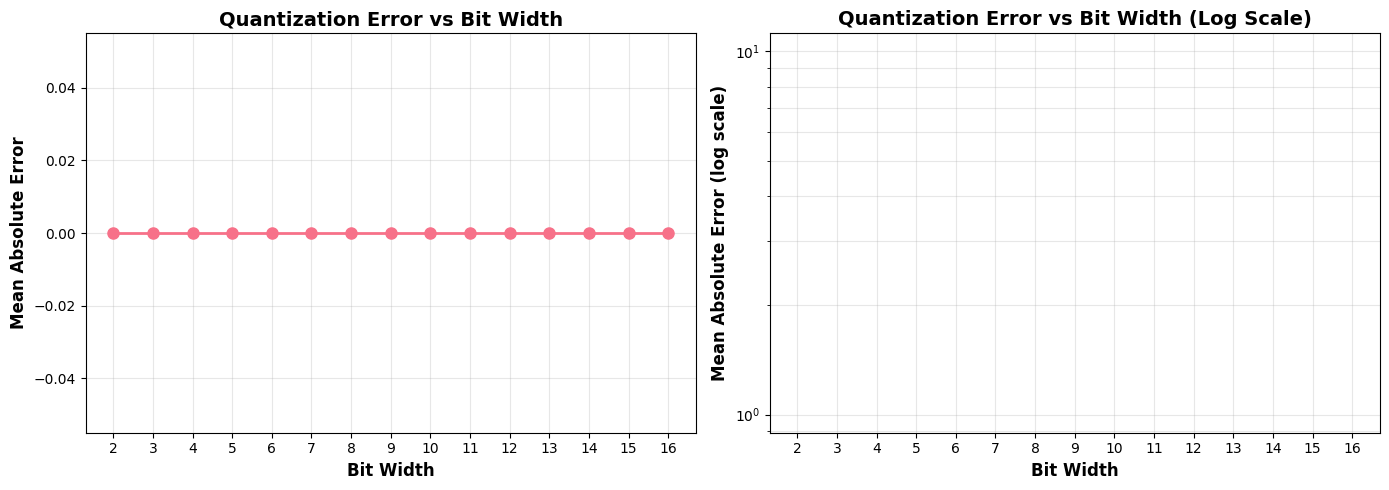


🔍 Quantization Error Analysis:
 2-bit: Error = 0.00000000
 3-bit: Error = 0.00000000
 4-bit: Error = 0.00000000
 5-bit: Error = 0.00000000
 6-bit: Error = 0.00000000
 7-bit: Error = 0.00000000
 8-bit: Error = 0.00000000
 9-bit: Error = 0.00000000
10-bit: Error = 0.00000000
11-bit: Error = 0.00000000
12-bit: Error = 0.00000000
13-bit: Error = 0.00000000
14-bit: Error = 0.00000000
15-bit: Error = 0.00000000
16-bit: Error = 0.00000000


In [8]:
def analyze_quantization_error():
    """
    Analyze how quantization error changes with bit width.
    """
    # Generate test weights
    test_weights = np.random.randn(1000, 1000) * 0.05
    
    bit_widths = np.arange(2, 17)
    errors = []
    
    for bits in bit_widths:
        quantized, _, _ = quantize_weights(test_weights, num_bits=bits)
        if quantized is not None:
            # TODO: Calculate mean absolute error
            # error = np.mean(np.abs(test_weights - quantized))
            error = None  # Replace with calculation
            errors.append(error if error is not None else 0)
        else:
            errors.append(0)
    
    # Plot error vs bit width
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Linear scale
    ax1.plot(bit_widths, errors, marker='o', linewidth=2, markersize=8)
    ax1.set_xlabel('Bit Width', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Mean Absolute Error', fontsize=12, fontweight='bold')
    ax1.set_title('Quantization Error vs Bit Width', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(bit_widths)
    
    # Log scale
    ax2.semilogy(bit_widths, errors, marker='s', linewidth=2, markersize=8, color='red')
    ax2.set_xlabel('Bit Width', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Mean Absolute Error (log scale)', fontsize=12, fontweight='bold')
    ax2.set_title('Quantization Error vs Bit Width (Log Scale)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, which='both')
    ax2.set_xticks(bit_widths)
    
    plt.tight_layout()
    plt.show()
    
    print("\n🔍 Quantization Error Analysis:")
    print("="*60)
    for bits, error in zip(bit_widths, errors):
        print(f"{bits:2d}-bit: Error = {error:.8f}")

# Run error analysis
analyze_quantization_error()

### Reflection Question 2.1
**Answer the following questions:**

1. What is the main benefit of quantization for TinyML deployment?
2. Looking at the error plots, how does quantization error change as bit width decreases?
3. What is the trade-off between using 8-bit vs 4-bit quantization?
4. Why might extreme quantization (2-bit, 1-bit) still be useful despite high error?

**Your Answer:**
<!-- TODO: Replace this comment with your detailed answers -->
1. The main benefit of quantization for TinyML deployment is that it significantly reduces the memory footprint and computational requirements of the model, enabling efficient inference on resource-constrained devices such as microcontrollers.
2. As bit width decreases, quantization error increases. The error plots show that reducing the number of bits leads to larger differences between the original and quantized weights, especially at very low bit widths.
3. The trade-off between using 8-bit and 4-bit quantization is that 8-bit quantization preserves more model accuracy with lower error, but uses more memory than 4-bit. 4-bit quantization further reduces memory and computation, but at the cost of higher quantization error and potential accuracy loss.
4. Extreme quantization, 2-bit, 1-bit, can still be useful because it allows models to run on extremely limited hardware, and in some applications, a rough approximation is sufficient. Additionally, such aggressive quantization can enable faster inference and lower power consumption, which are critical for some TinyML use cases.

---
## ✅ Part 2 Checklist: Parameter Quantization

**Before proceeding to Part 3, make sure you have completed all the following tasks:**

### Quantization Implementation:
- [ ] **TODO 2.1**: Calculated `num_levels = 2**num_bits`
- [ ] **TODO 2.2**: Calculated `scale = (w_max - w_min) / (num_levels - 1)`
- [ ] **TODO 2.3**: Quantized weights to integers
- [ ] **TODO 2.4**: Dequantized back to floats
- [ ] **Verification**: Histograms show quantized weight distributions
- [ ] **Verification**: Lower bit widths show more discrete values

### Error Analysis:
- [ ] **TODO 2.5**: Calculated mean absolute error
- [ ] **Verification**: Error decreases as bit width increases
- [ ] **Verification**: Both linear and log plots display correctly

### Understanding Tasks:
- [ ] **Reflection 2.1**: Answered all four questions about quantization benefits and trade-offs
- [ ] **Concept Check**: Understand quantization reduces memory and computation
- [ ] **Concept Check**: Understand error increases as bit width decreases

**🎯 Goal**: Implement quantization and understand memory-accuracy trade-offs.

---

---
# Part 3: Knowledge Distillation

Knowledge distillation trains a small "student" network to mimic a larger "teacher" network, transferring knowledge without transferring all parameters.

### Task 3.1: Implement Temperature-Based Distillation

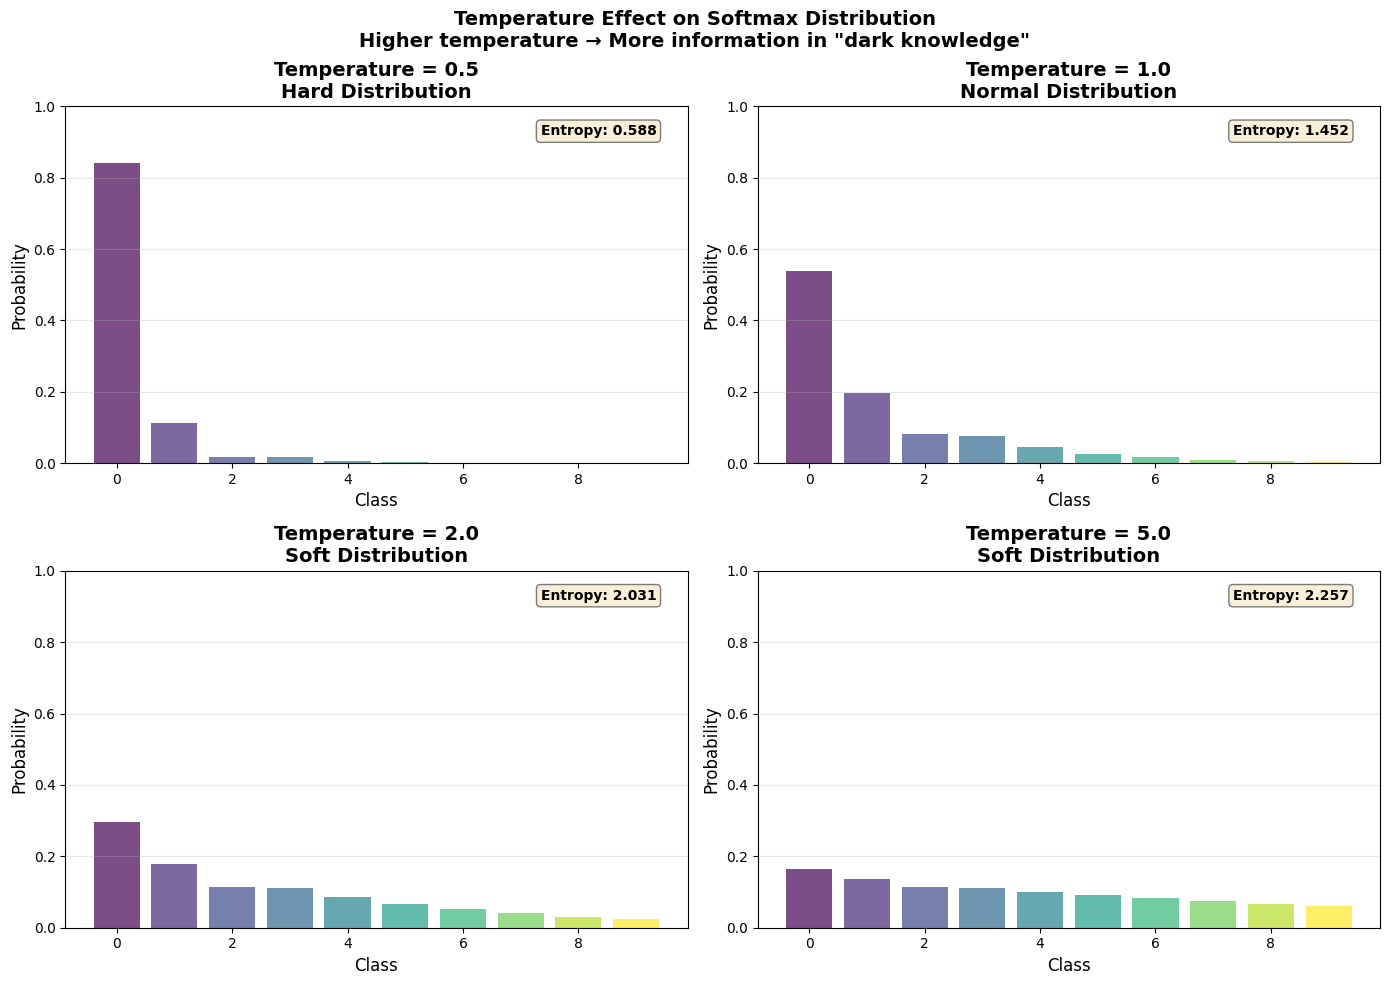


🌡️  Temperature Effects:
T < 1: Sharpens distribution (more confident)
T = 1: Standard softmax (normal)
T > 1: Softens distribution (reveals similarities between classes)

Knowledge Distillation uses high T to transfer 'dark knowledge'


In [9]:
def softmax_with_temperature(logits, temperature=1.0):
    """
    Compute softmax with temperature scaling.
    
    Higher temperature → softer probability distribution
    Lower temperature → harder probability distribution
    
    Args:
        logits: Raw network outputs
        temperature: Temperature parameter (T > 0)
        
    Returns:
        Softened probabilities
    """
    # TODO: Implement temperature-scaled softmax
    # Steps:
    # 1. Divide logits by temperature
    # 2. Apply standard softmax
    
    # Scale by temperature
    scaled_logits = logits / temperature  # Replace with logits / temperature
    
    # Apply softmax
    exp_logits = np.exp(scaled_logits - np.max(scaled_logits, axis=1, keepdims=True))
    probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
    
    return probabilities

def visualize_temperature_effect():
    """
    Visualize how temperature affects softmax output.
    """
    # Sample logits (raw network outputs)
    logits = np.array([[2.0, 1.0, 0.1, 0.05, -0.5, -1.0, -1.5, -2.0, -2.5, -3.0]])
    
    temperatures = [0.5, 1.0, 2.0, 5.0]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()
    
    for idx, T in enumerate(temperatures):
        try:
            probs = softmax_with_temperature(logits, temperature=T)
            
            if probs is not None:
                axes[idx].bar(range(10), probs[0], alpha=0.7, 
                             color=plt.cm.viridis(np.linspace(0, 1, 10)))
                axes[idx].set_title(f'Temperature = {T}\n' + 
                                   ('Hard' if T < 1 else 'Soft' if T > 1 else 'Normal') + 
                                   ' Distribution', 
                                   fontsize=14, fontweight='bold')
                axes[idx].set_xlabel('Class', fontsize=12)
                axes[idx].set_ylabel('Probability', fontsize=12)
                axes[idx].set_ylim([0, 1])
                axes[idx].grid(True, alpha=0.3, axis='y')
                
                # Add entropy measure
                entropy = -np.sum(probs[0] * np.log(probs[0] + 1e-10))
                axes[idx].text(0.95, 0.95, f'Entropy: {entropy:.3f}',
                              transform=axes[idx].transAxes,
                              ha='right', va='top',
                              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                              fontsize=10, fontweight='bold')
            else:
                axes[idx].text(0.5, 0.5, 'Not Implemented',
                              ha='center', va='center', fontsize=12,
                              transform=axes[idx].transAxes)
        except Exception as e:
            axes[idx].text(0.5, 0.5, f'Error\n{str(e)[:30]}',
                          ha='center', va='center', fontsize=10,
                          transform=axes[idx].transAxes)
    
    plt.suptitle('Temperature Effect on Softmax Distribution\n' + 
                 'Higher temperature → More information in "dark knowledge"',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n🌡️  Temperature Effects:")
    print("="*60)
    print("T < 1: Sharpens distribution (more confident)")
    print("T = 1: Standard softmax (normal)")
    print("T > 1: Softens distribution (reveals similarities between classes)")
    print("\nKnowledge Distillation uses high T to transfer 'dark knowledge'")

# Visualize temperature effect
visualize_temperature_effect()

### Task 3.2: Compare Teacher and Student Models

📊 Model Comparison:
Teacher Network (256 hidden units):
  Parameters: 19,210

Student Network (32 hidden units):
  Parameters: 2,410

✅ Student uses 87.5% fewer parameters
✅ Compression ratio: 8.0×


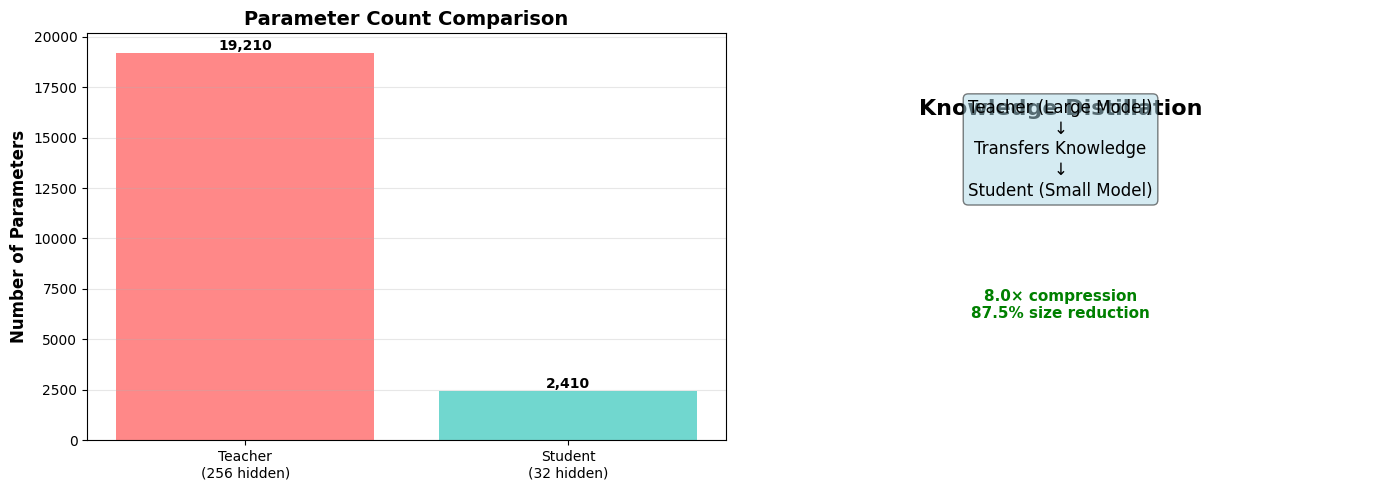

In [10]:
def compare_model_sizes():
    """
    Compare parameter counts between teacher and student networks.
    """
    # Teacher: Large network
    teacher = SimpleNN(input_size=64, hidden_size=256, output_size=10)
    
    # Student: Small network
    student = SimpleNN(input_size=64, hidden_size=32, output_size=10)
    
    # TODO: Calculate parameters for teacher and student
    teacher_params = teacher.count_parameters()
    student_params = student.count_parameters()
    
    print("📊 Model Comparison:")
    print("="*60)
    print(f"Teacher Network (256 hidden units):")
    print(f"  Parameters: {teacher_params:,}" if teacher_params else "  Parameters: Not calculated")
    print(f"\nStudent Network (32 hidden units):")
    print(f"  Parameters: {student_params:,}" if student_params else "  Parameters: Not calculated")
    
    if teacher_params and student_params:
        reduction = (1 - student_params / teacher_params) * 100
        compression = teacher_params / student_params
        print(f"\n✅ Student uses {reduction:.1f}% fewer parameters")
        print(f"✅ Compression ratio: {compression:.1f}×")
        
        # Visualize comparison
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Bar chart
        models = ['Teacher\n(256 hidden)', 'Student\n(32 hidden)']
        params = [teacher_params, student_params]
        colors = ['#ff6b6b', '#4ecdc4']
        
        bars = ax1.bar(models, params, color=colors, alpha=0.8)
        ax1.set_ylabel('Number of Parameters', fontsize=12, fontweight='bold')
        ax1.set_title('Parameter Count Comparison', fontsize=14, fontweight='bold')
        ax1.grid(True, alpha=0.3, axis='y')
        
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}',
                    ha='center', va='bottom', fontweight='bold')
        
        # Architecture visualization
        ax2.text(0.5, 0.8, 'Knowledge Distillation',
                ha='center', fontsize=16, fontweight='bold',
                transform=ax2.transAxes)
        ax2.text(0.5, 0.6, 'Teacher (Large Model)\n↓\nTransfers Knowledge\n↓\nStudent (Small Model)',
                ha='center', fontsize=12,
                transform=ax2.transAxes,
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
        ax2.text(0.5, 0.3, f'{compression:.1f}× compression\n{reduction:.1f}% size reduction',
                ha='center', fontsize=11, color='green', fontweight='bold',
                transform=ax2.transAxes)
        ax2.axis('off')
        
        plt.tight_layout()
        plt.show()

# Compare models
compare_model_sizes()

### Reflection Question 3.1
**Answer the following questions:**

1. What is "dark knowledge" in the context of knowledge distillation?
2. Why is temperature scaling important for knowledge distillation?
3. What are the advantages of knowledge distillation compared to simply training a small model from scratch?
4. In what scenarios would you prefer distillation over pruning or quantization?

**Your Answer:**
<!-- TODO: Replace this comment with your detailed answers -->
1. "Dark knowledge" refers to the information contained in the soft output probabilities of a teacher model, especially the relative probabilities assigned to incorrect classes. This knowledge helps the student model learn richer representations than just using hard labels.
2. Temperature scaling is important because it softens the output probabilities of the teacher model, making the differences between class probabilities more pronounced. This helps the student model learn from the full distribution of the teacher’s outputs, not just the most likely class.
3. Knowledge distillation allows a small model to learn from the nuanced behavior of a larger, well-trained teacher model, often resulting in better performance than training the small model from scratch. The student can capture generalization patterns and subtle cues present in the teacher’s outputs.
4. Distillation is preferred when you want a small model to closely mimic the performance and behavior of a larger model, especially when accuracy is critical. It is particularly useful when pruning or quantization alone would degrade accuracy too much, or when transferring knowledge to a different architecture or domain.

---
## ✅ Part 3 Checklist: Knowledge Distillation

**Before proceeding to Part 4, make sure you have completed all the following tasks:**

### Temperature Scaling:
- [ ] **TODO 3.1**: Implemented `scaled_logits = logits / temperature`
- [ ] **Verification**: Temperature plots show varying softness of distributions
- [ ] **Verification**: Higher temperature creates softer (more uniform) distributions
- [ ] **Verification**: Entropy values increase with temperature

### Model Comparison:
- [ ] **Verification**: Parameter counts display correctly for both models
- [ ] **Verification**: Student has significantly fewer parameters than teacher
- [ ] **Verification**: Compression ratio is calculated and displayed

### Understanding Tasks:
- [ ] **Reflection 3.1**: Answered all four questions about knowledge distillation
- [ ] **Concept Check**: Understand dark knowledge = class similarities in teacher
- [ ] **Concept Check**: Understand temperature reveals inter-class relationships

**🎯 Goal**: Understand knowledge distillation and temperature-based soft targets.

---

---
# Part 4: Compression Techniques Comparison

Compare all three compression techniques and analyze their trade-offs.

### Task 4.1: Comprehensive Comparison

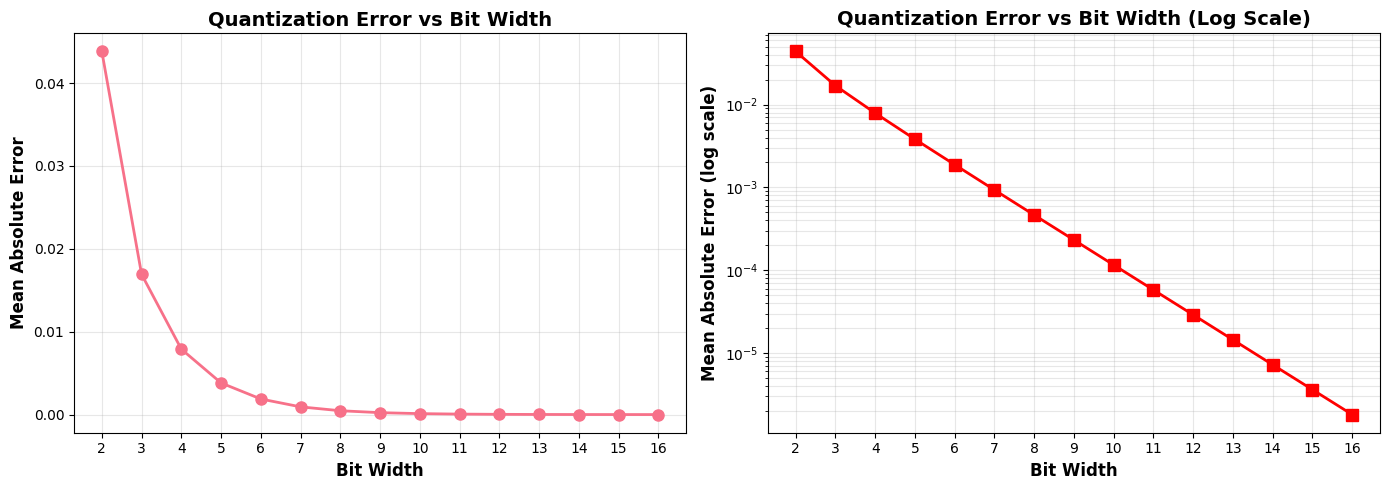


🔍 Quantization Error Analysis:
 2-bit: Error = 0.04380891
 3-bit: Error = 0.01691879
 4-bit: Error = 0.00789319
 5-bit: Error = 0.00381718
 6-bit: Error = 0.00188157
 7-bit: Error = 0.00093197
 8-bit: Error = 0.00046403
 9-bit: Error = 0.00023191
10-bit: Error = 0.00011575
11-bit: Error = 0.00005785
12-bit: Error = 0.00002892
13-bit: Error = 0.00001446
14-bit: Error = 0.00000722
15-bit: Error = 0.00000361
16-bit: Error = 0.00000181


In [11]:
def analyze_quantization_error():
    """
    Analyze how quantization error changes with bit width.
    """
    # Generate test weights
    test_weights = np.random.randn(1000, 1000) * 0.05
    
    bit_widths = np.arange(2, 17)
    errors = []
    
    for bits in bit_widths:
        quantized, _, _ = quantize_weights(test_weights, num_bits=bits)
        if quantized is not None:
            # TODO: Calculate mean absolute error
            # error = np.mean(np.abs(test_weights - quantized))
            error = np.mean(np.abs(test_weights - quantized))  # Replace with calculation
            errors.append(error if error is not None else 0)
        else:
            errors.append(0)
    
    # Plot error vs bit width
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Linear scale
    ax1.plot(bit_widths, errors, marker='o', linewidth=2, markersize=8)
    ax1.set_xlabel('Bit Width', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Mean Absolute Error', fontsize=12, fontweight='bold')
    ax1.set_title('Quantization Error vs Bit Width', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(bit_widths)
    
    # Log scale
    ax2.semilogy(bit_widths, errors, marker='s', linewidth=2, markersize=8, color='red')
    ax2.set_xlabel('Bit Width', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Mean Absolute Error (log scale)', fontsize=12, fontweight='bold')
    ax2.set_title('Quantization Error vs Bit Width (Log Scale)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, which='both')
    ax2.set_xticks(bit_widths)
    
    plt.tight_layout()
    plt.show()
    
    print("\n🔍 Quantization Error Analysis:")
    print("="*60)
    for bits, error in zip(bit_widths, errors):
        print(f"{bits:2d}-bit: Error = {error:.8f}")

# Run error analysis
analyze_quantization_error()

### Reflection Question 4.1
**Answer the following questions:**

1. Which compression technique provides the best size reduction? Which preserves accuracy best?
2. What are the deployment challenges of using pruned networks compared to quantized networks?
3. Can these techniques be combined? Give an example.
4. For a microcontroller with 256KB RAM running at 48MHz, which technique(s) would you recommend and why?

**Your Answer:**
<!-- TODO: Replace this comment with your detailed answers -->
1. Quantization typically provides the best size reduction, especially at very low bit widths. However, knowledge distillation often preserves accuracy best, as it allows a small model to mimic a larger, accurate teacher.
2. Pruned networks can be challenging to deploy because standard hardware and libraries are optimized for dense operations, making it harder to realize speed or memory benefits without specialized support. Quantized networks, on the other hand, are widely supported and can be efficiently run on most hardware.
3. Yes, these techniques can be combined. For example, you can first prune a network to remove unnecessary weights, then quantize the remaining weights to further reduce memory and computation requirements.
4. For a microcontroller with 256KB RAM running at 48MHz, quantization is highly recommended because it is well-supported, provides significant memory savings, and enables fast inference. If further reduction is needed, combining quantization with pruning or using a distilled small model can help fit within tight resource constraints while maintaining reasonable accuracy.

---
## ✅ Part 4 Checklist: Compression Comparison

**Make sure you have completed all the following tasks:**

### Verification Tasks:
- [ ] **Verification**: All three compression techniques show parameter counts
- [ ] **Verification**: Bar chart compares all techniques correctly
- [ ] **Verification**: Trade-offs summary displays

### Understanding Tasks:
- [ ] **Reflection 4.1**: Answered all four questions about technique comparison
- [ ] **Concept Check**: Understand each technique has different trade-offs
- [ ] **Concept Check**: Can recommend appropriate technique for specific constraints

**🎯 Goal**: Understand trade-offs and when to use each compression technique.

---

---
# Final Summary and Submission

## Homework Completion Checklist

### Part 1: Network Pruning ✓
- [ ] Implemented neural network forward pass
- [ ] Implemented parameter counting
- [ ] Implemented magnitude-based pruning
- [ ] Visualized pruning effects
- [ ] Answered reflection questions

### Part 2: Parameter Quantization ✓
- [ ] Implemented weight quantization
- [ ] Analyzed quantization at different bit widths
- [ ] Calculated quantization error
- [ ] Answered reflection questions

### Part 3: Knowledge Distillation ✓
- [ ] Implemented temperature-scaled softmax
- [ ] Visualized temperature effects
- [ ] Compared teacher and student models
- [ ] Answered reflection questions

### Part 4: Compression Comparison ✓
- [ ] Compared all three techniques
- [ ] Analyzed trade-offs
- [ ] Answered reflection questions

---

## Key Takeaways

After completing this homework, you should understand:

1. **Network Pruning**:
   - Removes redundant weights based on magnitude
   - Creates sparse networks with many zero weights
   - Can reduce parameters by 50-90% with minimal accuracy loss
   - Requires sparse matrix operations for full speedup

2. **Parameter Quantization**:
   - Reduces numerical precision (32-bit → 8-bit or lower)
   - 8-bit quantization: 4× memory reduction
   - Introduces quantization error (higher with lower bits)
   - Works on standard hardware (especially INT8 operations)

3. **Knowledge Distillation**:
   - Trains small model to mimic large model
   - Uses temperature scaling to transfer "dark knowledge"
   - Often achieves better accuracy than training small model from scratch
   - Results in fully dense network (no special hardware needed)

4. **Trade-offs**:
   - Pruning: Best compression, needs sparse ops support
   - Quantization: Good compression, broad hardware support
   - Distillation: Best accuracy retention, flexible deployment
   - Techniques can be combined for maximum compression

5. **TinyML Applications**:
   - Enable ML on microcontrollers and edge devices
   - Critical for battery-powered and resource-constrained deployments
   - Balance accuracy, size, latency, and power consumption

---

## Submission Instructions

1. **Execute all cells** to ensure your code runs without errors
2. **Answer all reflection questions** in the designated markdown cells
3. **Verify all visualizations** display correctly
4. **Save your notebook** with all outputs preserved
5. **Submit the .ipynb file** through the course portal

---

**Congratulations on completing Homework 4! 🎉**

You now understand the key techniques for deploying neural networks on resource-constrained devices, an essential skill for real-world ML applications.